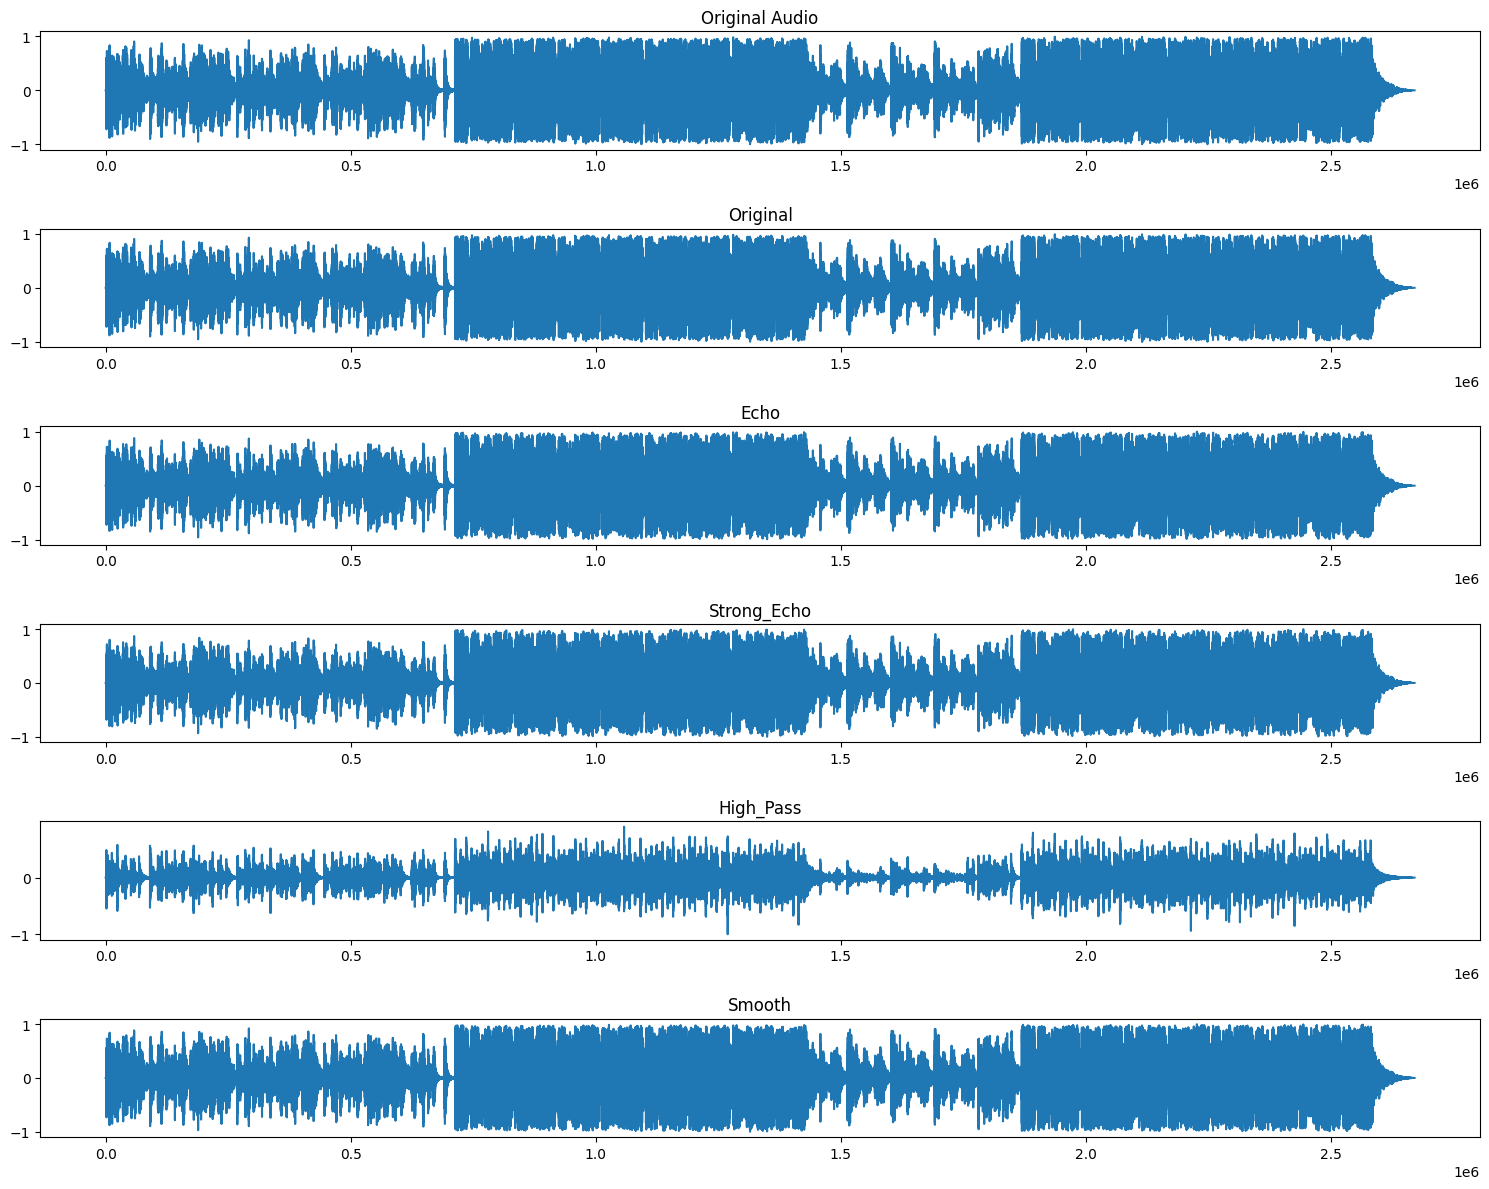

Processing Completed Successfully


In [1]:
from pydub import AudioSegment
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve, lfilter

# -----------------------------
# Load Audio File
# -----------------------------
audio = AudioSegment.from_mp3("alec_koff-carnaval-484622.mp3")

# Convert to Mono
audio = audio.set_channels(1)

# Extract Samples
samples = np.array(audio.get_array_of_samples(), dtype=np.float32)

# Normalize
samples = samples / np.max(np.abs(samples))

# -----------------------------
# Define Different Impulse Responses
# -----------------------------
kernels = {
    "Original": np.array([1], dtype=np.float32),

    "Echo": np.array([1,0,1], dtype=np.float32),

    "Strong_Echo": np.array([1,0,1,0,1], dtype=np.float32),

    "High_Pass": np.array([1,-1], dtype=np.float32),

    "Smooth": np.array([0.2,0.6,0.2], dtype=np.float32)
}

plt.figure(figsize=(15,12))

plt.subplot(len(kernels)+1,1,1)
plt.plot(samples)
plt.title("Original Audio")

count=2

for name,kernel in kernels.items():

    output = convolve(samples,kernel,mode="same")

    output = output/np.max(np.abs(output))

    plt.subplot(len(kernels)+1,1,count)
    plt.plot(output)
    plt.title(name)

    output_int16=(output*32767).astype(np.int16)

    new_audio=AudioSegment(
        output_int16.tobytes(),
        frame_rate=audio.frame_rate,
        sample_width=2,
        channels=1
    )

    new_audio.export(f"{name}.wav",format="wav")

    count+=1

# -----------------------------
# Inverse Filtering
# -----------------------------
inverse_kernel=np.array([1,-0.5,0.25,-0.125,0.0625])

inverse=lfilter(inverse_kernel,[1],samples)

inverse=inverse/np.max(np.abs(inverse))

inverse_int16=(inverse*32767).astype(np.int16)

inverse_audio=AudioSegment(
    inverse_int16.tobytes(),
    frame_rate=audio.frame_rate,
    sample_width=2,
    channels=1
)

inverse_audio.export("Inverse_Filter_Output.wav",format="wav")

plt.tight_layout()

plt.show()

print("Processing Completed Successfully")

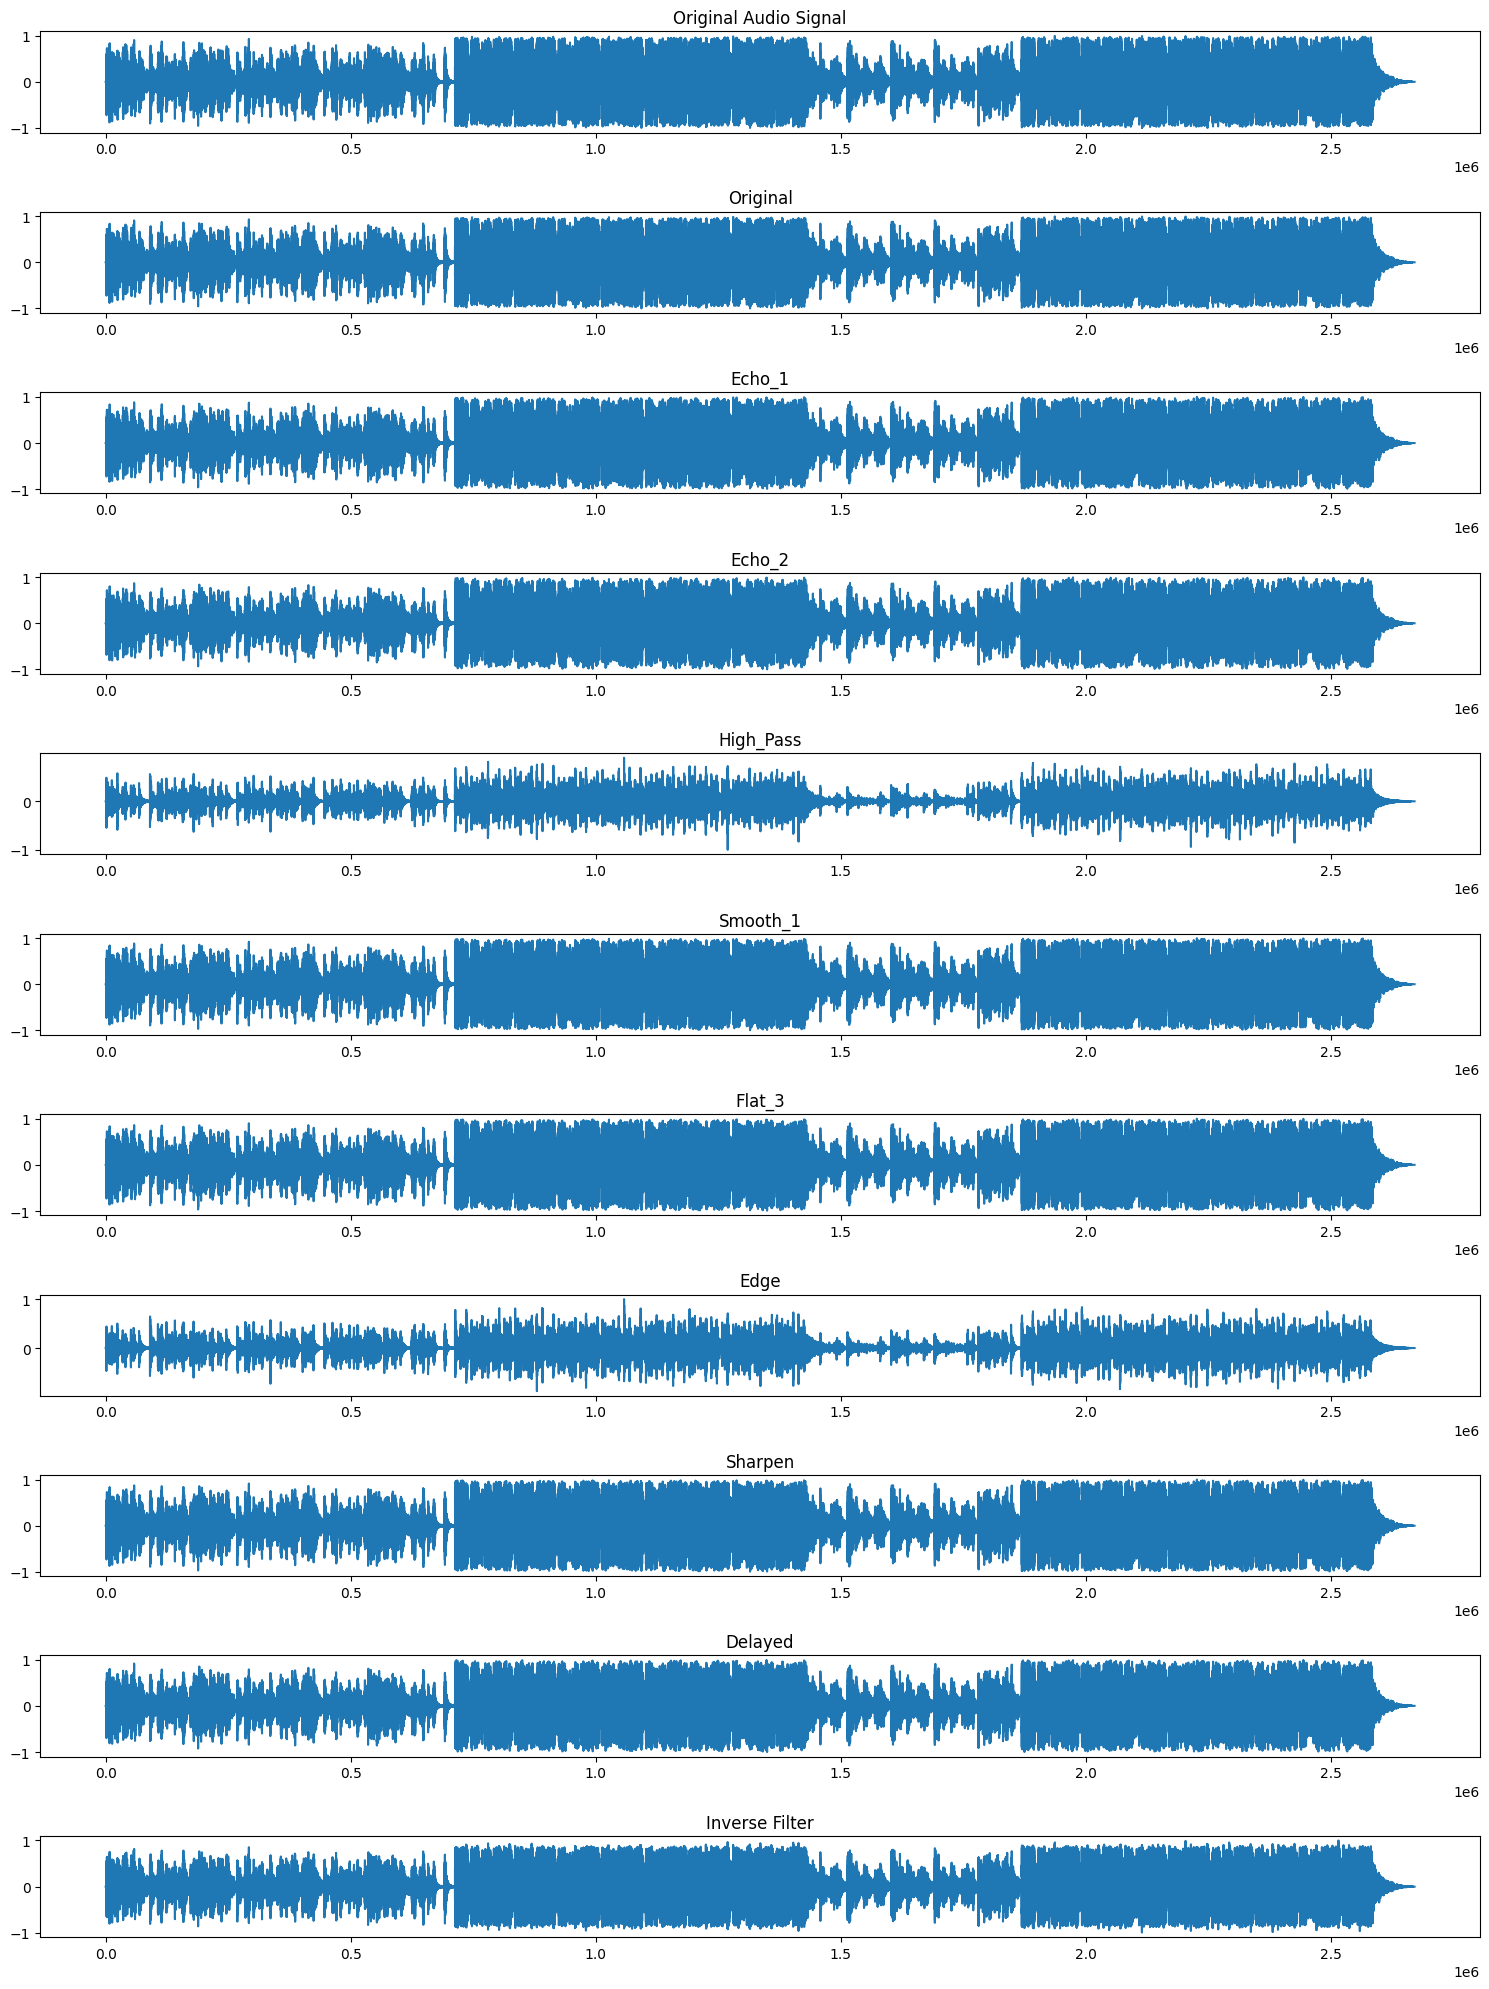

Processing Completed Successfully


In [2]:
# ------------------------------------------------------------
# Import Required Libraries
# ------------------------------------------------------------

# Used for loading and exporting audio files
from pydub import AudioSegment

# Used for numerical operations
import numpy as np

# Used for plotting graphs
import matplotlib.pyplot as plt

# Used for convolution and inverse filtering
from scipy.signal import convolve, lfilter

# ------------------------------------------------------------
# Load the Audio File
# ------------------------------------------------------------

# Load the MP3 audio file
audio = AudioSegment.from_mp3("alec_koff-carnaval-484622.mp3")

# Convert the audio into a single channel (mono)
audio = audio.set_channels(1)

# ------------------------------------------------------------
# Extract and Normalize Audio Samples
# ------------------------------------------------------------

# Convert audio data into a NumPy array
samples = np.array(
    audio.get_array_of_samples(),
    dtype=np.float32
)

# Normalize the audio signal
samples = samples / np.max(np.abs(samples))

# ------------------------------------------------------------
# Define Different Impulse Responses
# ------------------------------------------------------------

kernels = {

    # Original signal
    "Original": np.array([1], dtype=np.float32),

    # Mild echo effect
    "Echo_1": np.array([1, 0, 1], dtype=np.float32),

    # Strong echo effect
    "Echo_2": np.array([1, 0, 1, 0, 1], dtype=np.float32),

    # High-pass filter
    "High_Pass": np.array([1, -1], dtype=np.float32),

    # Smoothing filter
    "Smooth_1": np.array([0.2, 0.6, 0.2], dtype=np.float32),

    # Moving average filter
    "Flat_3": np.array([1, 1, 1], dtype=np.float32),

    # Edge detection filter
    "Edge": np.array([1, 0, -1], dtype=np.float32),

    # Sharpening filter
    "Sharpen": np.array([1, 2, 1], dtype=np.float32),

    # Delayed signal
    "Delayed": np.array([1, 0, 0, 1], dtype=np.float32),
}

# ------------------------------------------------------------
# Create a Figure for Plotting
# ------------------------------------------------------------

plt.figure(figsize=(15, 20))

# ------------------------------------------------------------
# Plot the Original Signal
# ------------------------------------------------------------

plt.subplot(len(kernels) + 2, 1, 1)
plt.plot(samples)
plt.title("Original Audio Signal")

# ------------------------------------------------------------
# Initialize Counter
# ------------------------------------------------------------

count = 2

# ------------------------------------------------------------
# Apply Convolution to Each Kernel
# ------------------------------------------------------------

for name, kernel in kernels.items():

    # Perform convolution
    output = convolve(samples, kernel, mode="same")

    # Normalize the output signal
    output = output / np.max(np.abs(output))

    # Plot the output signal
    plt.subplot(len(kernels) + 2, 1, count)
    plt.plot(output)
    plt.title(name)

    # Convert the signal into a 16-bit integer format
    output_int16 = (output * 32767).astype(np.int16)

    # Create a new audio segment
    new_audio = AudioSegment(
        output_int16.tobytes(),
        frame_rate=audio.frame_rate,
        sample_width=2,
        channels=1
    )

    # Export the audio file
    new_audio.export(f"{name}.wav", format="wav")

    # Increment counter
    count += 1

# ------------------------------------------------------------
# Perform Inverse Filtering
# ------------------------------------------------------------

# Define the inverse filter kernel
inverse_kernel = np.array(
    [1, -0.5, 0.25, -0.125, 0.0625],
    dtype=np.float32
)

# Apply inverse filtering
inverse = lfilter(inverse_kernel, [1], samples)

# Normalize the output
inverse = inverse / np.max(np.abs(inverse))

# ------------------------------------------------------------
# Plot the Inverse Filter Output
# ------------------------------------------------------------

plt.subplot(len(kernels) + 2, 1, count)
plt.plot(inverse)
plt.title("Inverse Filter")

# ------------------------------------------------------------
# Convert the Output into Audio Format
# ------------------------------------------------------------

inverse_int16 = (inverse * 32767).astype(np.int16)

inverse_audio = AudioSegment(
    inverse_int16.tobytes(),
    frame_rate=audio.frame_rate,
    sample_width=2,
    channels=1
)

# ------------------------------------------------------------
# Save the Audio File
# ------------------------------------------------------------

inverse_audio.export(
    "Inverse_Filter_Output.wav",
    format="wav"
)

# ------------------------------------------------------------
# Display the Graphs
# ------------------------------------------------------------

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Display Completion Message
# ------------------------------------------------------------

print("Processing Completed Successfully")